<a href="https://colab.research.google.com/github/rajanaids-hub/BASICS-ML/blob/main/NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Naive Bayes Classifier: A Hands-on Introduction for Students

This notebook provides a complete hands-on guide to understanding and implementing the Naive Bayes classification algorithm. We will cover the core concepts, the underlying theory, and a practical example using Python's `scikit-learn` library.

## 1. Introduction to Naive Bayes

Naive Bayes is a family of probabilistic classifiers based on applying Bayes' theorem with strong (naive) independence assumptions between the features. It's a simple yet surprisingly effective algorithm, especially for text classification and spam detection.

### Why 'Naive'?

The 'naive' part comes from the assumption that all features in the dataset are independent of each other given the class variable. In real-world scenarios, features are rarely completely independent, but despite this simplification, Naive Bayes often performs well.

### Key Concepts:
*   **Probabilistic Model**: It predicts the probability that a given sample belongs to a particular class.
*   **Bayes' Theorem**: The foundation of the algorithm, which helps us calculate conditional probabilities.
*   **Feature Independence**: The 'naive' assumption that simplifies calculations.

## 2. Bayes' Theorem Refresher

Bayes' theorem describes the probability of an event, based on prior knowledge of conditions that might be related to the event. Mathematically, it's expressed as:

$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$

Where:
*   $P(A|B)$ is the **posterior probability**: the probability of hypothesis A given the evidence B.
*   $P(B|A)$ is the **likelihood**: the probability of evidence B given that hypothesis A is true.
*   $P(A)$ is the **prior probability**: the probability of hypothesis A being true (before observing the evidence B).
*   $P(B)$ is the **marginal probability**: the probability of evidence B.

In the context of classification, we want to find the probability of a class (A) given observed features (B).

## 3. Setting Up Our Environment

First, we need to import the necessary libraries. We'll use `pandas` for data handling, `scikit-learn` for the Naive Bayes classifier and data splitting, and `matplotlib` and `seaborn` for visualization.

In [1]:
# Import necessary libraries
import pandas as pd # For data manipulation and analysis
import numpy as np # For numerical operations, especially with arrays
from sklearn.model_selection import train_test_split # To split data into training and testing sets
from sklearn.naive_bayes import GaussianNB # Gaussian Naive Bayes classifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # For evaluating model performance
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualizations
import seaborn as sns # For making statistical graphics based on matplotlib

## 4. Loading and Exploring the Dataset

For this hands-on example, we'll use a built-in dataset from `scikit-learn`. Let's use the Iris dataset, which is a classic for classification tasks. It contains measurements of iris flowers and their corresponding species.

In [2]:
from sklearn.datasets import load_iris # Import the Iris dataset loader

# Load the Iris dataset
iris = load_iris()
X = iris.data # Features (sepal length, sepal width, petal length, petal width)
y = iris.target # Target labels (species: setosa, versicolor, virginica)

# Create a DataFrame for better viewing
df = pd.DataFrame(X, columns=iris.feature_names) # Create DataFrame from features
df['species'] = y # Add the target species column

# Display the first 5 rows of the dataset
print("First 5 rows of the Iris dataset:")
display(df.head()) # Use display() for better rendering in Colab

# Display basic information about the dataset
print("\nDataset Information:")
df.info()

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

First 5 rows of the Iris dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 5. Data Splitting: Training and Testing Sets

Before training any model, it's crucial to split our dataset into two parts:
1.  **Training set**: Used to train the model.
2.  **Testing set**: Used to evaluate the model's performance on unseen data.

This helps us assess how well our model generalizes to new data, preventing overfitting.

In [3]:
# Split the dataset into training and testing sets
# test_size=0.30 means 30% of data will be used for testing
# random_state for reproducibility, ensuring the same split each time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Print the shapes of the new datasets to verify the split
print(f"Shape of X_train: {X_train.shape}") # Features for training
print(f"Shape of X_test: {X_test.shape}")   # Features for testing
print(f"Shape of y_train: {y_train.shape}") # Target labels for training
print(f"Shape of y_test: {y_test.shape}")     # Target labels for testing

Shape of X_train: (105, 4)
Shape of X_test: (45, 4)
Shape of y_train: (105,)
Shape of y_test: (45,)


## 6. Building and Training the Gaussian Naive Bayes Model

For continuous features like those in the Iris dataset, the `GaussianNB` (Gaussian Naive Bayes) classifier is typically used. It assumes that the continuous values associated with each class are distributed according to a Gaussian (normal) distribution.

We will initialize the model and then `fit` it to our training data.

In [4]:
# Initialize the Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Train the model using the training data
# The 'fit' method learns the relationship between features (X_train) and target (y_train)
gnb.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully!")

Gaussian Naive Bayes model trained successfully!


## 7. Making Predictions

Once the model is trained, we can use it to make predictions on the unseen test data. The `predict` method will output the predicted class label for each sample in `X_test`.

In [5]:
# Make predictions on the test set
# The model predicts the class labels for the features in X_test
y_pred = gnb.predict(X_test)

# Display the first few actual and predicted values for comparison
print("Actual labels (first 10):", y_test[:10])
print("Predicted labels (first 10):", y_pred[:10])

Actual labels (first 10): [1 0 2 1 1 0 1 2 1 1]
Predicted labels (first 10): [1 0 2 1 1 0 1 2 1 1]


## 8. Evaluating Model Performance

After making predictions, we need to evaluate how well our model performed. Common metrics for classification include:
*   **Accuracy Score**: The proportion of correctly classified samples.
*   **Confusion Matrix**: A table showing the number of correct and incorrect predictions for each class.
*   **Classification Report**: Provides precision, recall, and F1-score for each class.

Accuracy Score: 0.98

Confusion Matrix:
[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


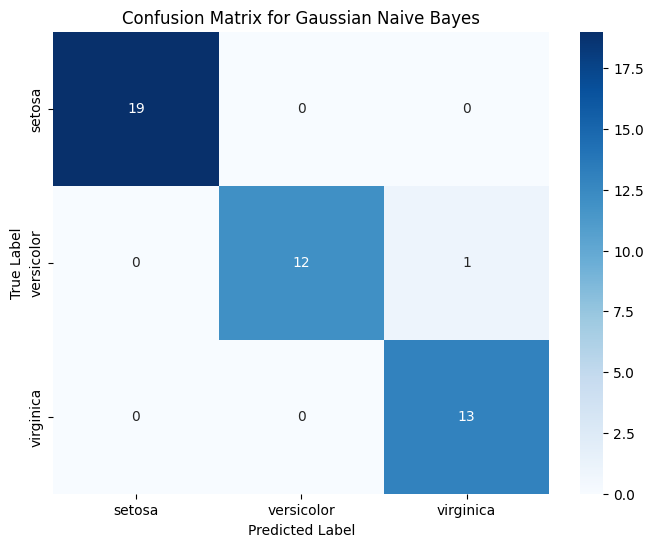


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [6]:
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2f}") # Print accuracy, formatted to 2 decimal places

# Generate the confusion matrix
# This matrix shows the count of true positives, true negatives, false positives, and false negatives
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6)) # Set the figure size
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', # 'annot=True' displays values, 'fmt='d'' formats as integers
            xticklabels=iris.target_names, yticklabels=iris.target_names) # Label axes with actual species names
plt.xlabel('Predicted Label') # X-axis label
plt.ylabel('True Label')      # Y-axis label
plt.title('Confusion Matrix for Gaussian Naive Bayes') # Plot title
plt.show() # Display the plot

# Generate a classification report
# This provides precision, recall, f1-score, and support for each class
class_report = classification_report(y_test, y_pred, target_names=iris.target_names)
print("\nClassification Report:")
print(class_report)

## 9. Lab Experiment Ideas for Students

Here are some ideas for your students to experiment with and deepen their understanding of Naive Bayes:

1.  **Try different `test_size` values**: Modify the `test_size` parameter in `train_test_split` (e.g., 0.2, 0.4) and observe how it affects the accuracy and other evaluation metrics. Does using more training data always lead to better results?

2.  **Explore other Naive Bayes variants**: `scikit-learn` offers other Naive Bayes classifiers like `MultinomialNB` (for discrete counts, common in text classification) and `BernoulliNB` (for binary features). Encourage students to try `MultinomialNB` or `BernoulliNB` if they can find or create a suitable dataset (e.g., text data).

    *   **Hint**: For `MultinomialNB`, the features should typically be counts (like word counts in a document). For `BernoulliNB`, features should be binary (presence/absence).

3.  **Feature Scaling**: While Naive Bayes is generally less sensitive to feature scaling than some other algorithms (like SVMs or k-NN), students can experiment with applying `StandardScaler` or `MinMaxScaler` to the features (`X`) before training the model. Does it improve or worsen performance for Gaussian Naive Bayes?

    *   **Hint**: Import `StandardScaler` from `sklearn.preprocessing`.

4.  **Visualize Decision Boundaries (Advanced)**: For two features, students can try to visualize the decision boundary created by the Naive Bayes classifier. This might require selecting only two features from the Iris dataset and plotting them.

5.  **Compare with other classifiers**: Train a simple Logistic Regression or K-Nearest Neighbors (K-NN) classifier on the same dataset and compare its performance with Gaussian Naive Bayes. Which one performs better for this specific dataset and why might that be?

    *   **Hint**: Import `LogisticRegression` or `KNeighborsClassifier` from `sklearn.linear_model` or `sklearn.neighbors` respectively.